# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../week03/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [3]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


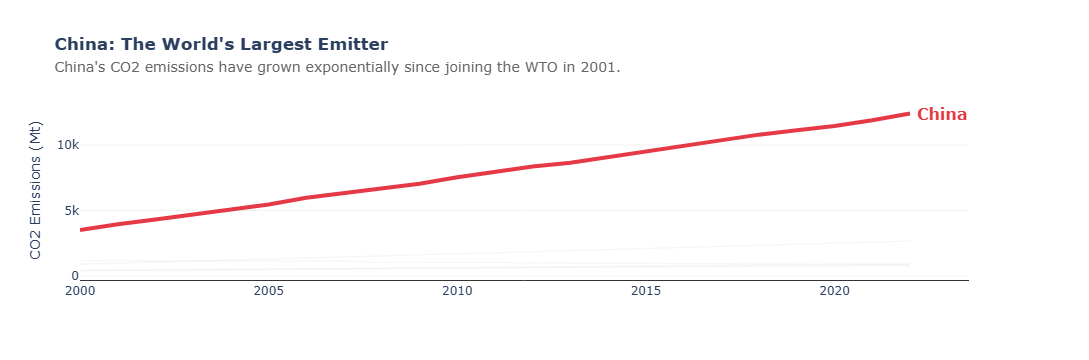

In [10]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
asia_df = df[df['Region'] == 'Asia']
countries = asia_df['Country'].unique()
highlight_country = "China" # Changed to China

fig1 = go.Figure()

for country in countries:
    country_data = asia_df[asia_df['Country'] == country]
    
    if country == highlight_country:
        line_color = '#E63946'  # A strong red to represent China's massive impact
        line_width = 4
        opacity = 1
    else:
        line_color = '#EEEEEE'  # Very light grey so they don't distract
        line_width = 1.2
        opacity = 0.5

    fig1.add_trace(go.Scatter(
        x=country_data['Year'], 
        y=country_data['CO2_Mt'],
        mode='lines',
        line=dict(color=line_color, width=line_width),
        opacity=opacity,
        showlegend=False
    ))

# Label for China
last_point = asia_df[(asia_df['Country'] == highlight_country) & (asia_df['Year'] == 2022)]
fig1.add_annotation(
    x=2022, y=last_point['CO2_Mt'].values[0],
    text=f" <b>{highlight_country}</b>",
    showarrow=False, xanchor="left",
    font=dict(color='#E63946', size=16)
)

fig1.update_layout(
    title="<b>China: The World's Largest Emitter</b><br><span style='font-size:14px; color:#666666'>China's CO2 emissions have grown exponentially since joining the WTO in 2001.</span>",
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, linecolor='#333333'),
    yaxis=dict(title="CO2 Emissions (Mt)", showgrid=True, gridcolor='#F2F2F2', zeroline=False),
    margin=dict(r=120)
)

fig1.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


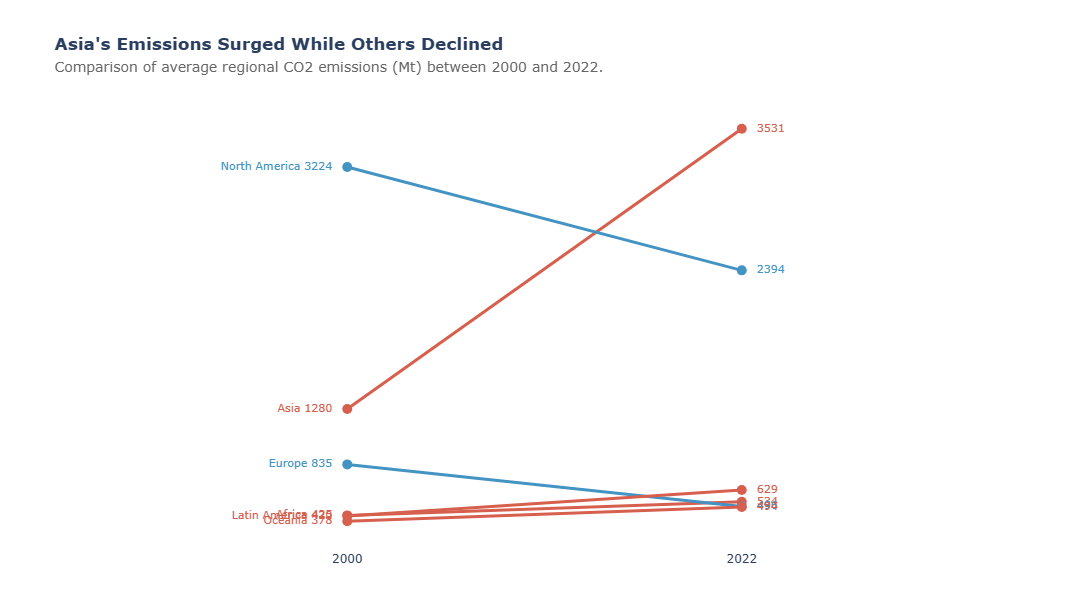

In [24]:
# Task 2 — Slopegraph: Direct Labels 
# YOUR CODE HERE

# 1. Aggregate data by Region and filter for start/end years
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

fig2 = go.Figure()

for r in slope_df['Region'].unique():
    reg_data = slope_df[slope_df['Region'] == r].sort_values('Year')
    val_00 = reg_data[reg_data['Year'] == 2000]['CO2_Mt'].values[0]
    val_22 = reg_data[reg_data['Year'] == 2022]['CO2_Mt'].values[0]
    
    # Use color to encode direction: Red for increase, Blue for decrease
    color = "#D6604D" if val_22 > val_00 else "#4393C3"

    # Create slope lines with direct labels to avoid legends
    fig2.add_trace(go.Scatter(
        x=reg_data['Year'].astype(str), 
        y=reg_data['CO2_Mt'],
        mode='lines+markers+text',
        name=r,
        text=[f"{r} {val_00:.0f}  ", f"  {val_22:.0f}"],
        textposition=["middle left", "middle right"],
        textfont=dict(size=11, color=color),
        line=dict(color=color, width=3),
        marker=dict(size=10),
        showlegend=False,
        cliponaxis=False # Ensures text isn't cut off at the edges
    ))

# 2. Apply clean design principles (No borders, no Y-axis, clear insight)
fig2.update_layout(
    title="<b>Asia's Emissions Surged While Others Declined</b><br><span style='font-size:14px; color:#666666'>Comparison of average regional CO2 emissions (Mt) between 2000 and 2022.</span>",
    plot_bgcolor='white',
    height=600,
    xaxis=dict(
        showgrid=False, 
        zeroline=False,
        range=[-0.5, 1.5] # Adds padding for the labels
    ),
    yaxis=dict(
        showgrid=False, 
        zeroline=False, 
        showticklabels=False # Labels at endpoints make Y-axis redundant
    ),
    margin=dict(l=150, r=150, t=100, b=50)
)

fig2.show()